# Text Mining the Epstein Files (DOJ Dataset 12)

This notebook implements a systematic pipeline for extracting an interaction network ('Who met whom, when, and where') from unstructured, noisy documents. 

**Pipeline Overview:**
1. **Setup & Ingestion:** Extract text from PDFs and clean OCR/redaction artifacts.
2. **EDA:** Understand the linguistic structure of the dataset.
3. **NER Pipeline:** Extract People, Organizations, and Locations using `spaCy`.
4. **Relation Extraction (RE):** Identify interactions using dependency parsing (Heuristic approach) and prepare for LLM extraction.
5. **Knowledge Graph Construction:** Visualize the findings using `NetworkX`.

## Phase 1: Environment Setup
Install the required libraries for NLP, PDF processing, and network visualization.

In [7]:
%pip install -q PyMuPDF spacy networkx matplotlib seaborn pandas transformers accelerate bitsandbytes
!python -m spacy download en_core_web_sm
print('Dependencies installed successfully!')

Note: you may need to restart the kernel to use updated packages.

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 165.2 kB/s eta 0:01:18
     --------------------------------------- 0.0/12.8 MB 245.8 kB/s eta 0:00:52
     --------------------------------------- 0.1/12.8 MB 357.2 kB/s eta 0:00:36
     -- ------------------------------------- 0.8/12.8 MB 3.8 MB/s eta 0:00:04
     ------- -------------------------------- 2.3/12.8 MB 9.8 MB/s eta 0:00:02
     ------------- -------------------------- 4.4/12.8 MB 15.5 MB/s eta 0:00:01
     ---------------------- ----------------- 7.2/12.8 MB 23.2 MB/s eta 0:00:01
     ------------------------------ -------- 10.0/12.8 MB 29.1 MB/s eta 0:00:01
     --------------------------------------  12.8/12.8 MB 73.1 MB/s eta 0:00:01

## Phase 2: Data Loading & Preprocessing
DOJ Data Set 12 PDFs are already available in `data/raw_pdfs` prepared by `crawl.py`. This phase loads valid PDFs and cleans common OCR/redaction artifacts before NLP processing.

In [34]:
import fitz  # PyMuPDF
import os
import re
from collections import Counter
from pathlib import Path

RAW_PDF_DIR = "data/raw_pdfs"
MAX_FILES_TO_LOAD = 20  # Set to None to use all PDFs in RAW_PDF_DIR

NOISE_LINE_MARKERS = [
    "skip to main content",
    "menu search",
    "epstein library",
    "privacy notice",
    "are you 18 years of age or older",
    "return to the top of the page",
    "contact the department",
    "signup for email updates",
    "links to other government and non-government sites",
    "u.s. department of justice",
    "950 pennsylvania avenue",
]

def is_valid_pdf_file(filepath):
    try:
        with open(filepath, "rb") as f:
            return f.read(5) == b"%PDF-"
    except OSError:
        return False

def load_pdf_text(filepath):
    """Extracts raw text from one PDF file."""
    if not os.path.exists(filepath) or not is_valid_pdf_file(filepath):
        return None
    with fitz.open(filepath) as doc:
        return "\n".join(page.get_text("text") for page in doc)

def load_all_pdf_texts(folder_path, max_files=None):
    """Loads and concatenates text from all valid PDFs in a folder."""
    pdf_paths = sorted(Path(folder_path).glob("*.pdf"))
    if max_files is not None:
        pdf_paths = pdf_paths[:max_files]

    chunks = []
    valid_paths = []
    for pdf_path in pdf_paths:
        text = load_pdf_text(str(pdf_path))
        if text:
            chunks.append(text)
            valid_paths.append(str(pdf_path))

    return "\n".join(chunks), valid_paths

def strip_pdf_boilerplate(text, repeated_line_threshold=30):
    """Removes recurring headers/footers and navigation boilerplate from extracted PDF text."""
    lines = [re.sub(r"\s+", " ", line).strip() for line in text.splitlines()]
    non_empty = [line for line in lines if line]
    line_counts = Counter(non_empty)

    cleaned_lines = []
    for line in lines:
        if not line:
            continue
        lower = line.lower()

        if line_counts[line] >= repeated_line_threshold:
            continue
        if any(marker in lower for marker in NOISE_LINE_MARKERS):
            continue
        if re.fullmatch(r"page\s*\d+(\s*of\s*\d+)?", lower):
            continue
        if re.fullmatch(r"\d{1,4}", line):
            continue
        if len(line) <= 1:
            continue

        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)

def clean_text(text):
    """Standardizes whitespace and handles redaction markers systematically."""
    text = text.replace("[REDACTED]", "REDACTED_ENTITY")
    text = strip_pdf_boilerplate(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

raw_text, used_files = load_all_pdf_texts(RAW_PDF_DIR, max_files=MAX_FILES_TO_LOAD)
if not used_files:
    raise FileNotFoundError(
        f"No valid PDFs were found in {RAW_PDF_DIR}. Run crawl.py first to populate this folder."
    )

print(f"Loaded text from {len(used_files)} valid PDF files.")
raw_length = len(raw_text)
cleaned_text = clean_text(raw_text)
print(f"Raw text length: {raw_length} characters")
print(f"Cleaned text length: {len(cleaned_text)} characters")

Loaded text from 20 valid PDF files.
Raw text length: 1180477 characters
Cleaned text length: 1024088 characters


## Phase 3: Exploratory Data Analysis (EDA)
Understanding sentence length distributions helps us tune our Relation Extraction window.

Sentence filtering kept 4382 of 6909 sentences and created 4 chunks for processing.


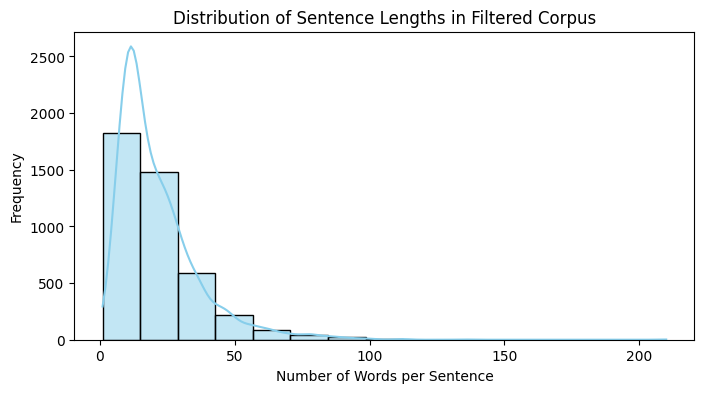

In [35]:
import re
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

nlp = spacy.load('en_core_web_sm')

NOISE_SENTENCE_MARKERS = [
    'links to other government and non-government sites',
    'return to the top of the page',
    'contact usa.gov',
    'privacy notice',
    'epstein library',
    'menu search',
]

def is_informative_sentence(sentence_text):
    text = sentence_text.strip()
    if not text:
        return False

    lowered = text.lower()
    if any(marker in lowered for marker in NOISE_SENTENCE_MARKERS):
        return False

    words = re.findall(r"[A-Za-z][A-Za-z'-]*", text)
    if len(words) < 5 or len(words) > 80:
        return False

    alpha_ratio = sum(ch.isalpha() for ch in text) / max(len(text), 1)
    if alpha_ratio < 0.50:
        return False

    if re.fullmatch(r"(page\s*\d+(\s*of\s*\d+)?)|\d+", lowered):
        return False

    return True

def chunk_text(text, max_chars=180000):
    """Chunks text at sentence-like boundaries to keep spaCy processing memory-safe."""
    segments = re.split(r"(?<=[\n.!?])\s+", text)
    chunks = []
    current = []
    current_len = 0

    for segment in segments:
        piece = segment.strip()
        if not piece:
            continue
        piece_len = len(piece) + 1

        if current and current_len + piece_len > max_chars:
            chunks.append(' '.join(current))
            current = [piece]
            current_len = piece_len
        else:
            current.append(piece)
            current_len += piece_len

    if current:
        chunks.append(' '.join(current))

    return chunks

raw_chunks = chunk_text(cleaned_text, max_chars=180000)
raw_sentences = []
for doc_chunk in nlp.pipe(raw_chunks, batch_size=1):
    raw_sentences.extend(sent.text.strip() for sent in doc_chunk.sents)

filtered_sentences = [sent for sent in raw_sentences if is_informative_sentence(sent)]
filtered_text = ' '.join(filtered_sentences)

if filtered_text:
    filtered_chunks = chunk_text(filtered_text, max_chars=180000)
    docs = list(nlp.pipe(filtered_chunks, batch_size=1))
    print(
        f'Sentence filtering kept {len(filtered_sentences)} of {len(raw_sentences)} sentences '
        f'and created {len(docs)} chunks for processing.'
    )
else:
    docs = list(nlp.pipe(raw_chunks, batch_size=1))
    print('Sentence filtering removed all content; using unfiltered chunked text.')

doc = docs[0] if docs else nlp('')
sentence_lengths = [len(sent.text.split()) for d in docs for sent in d.sents]

plt.figure(figsize=(8, 4))
sns.histplot(sentence_lengths, bins=15, kde=True, color='skyblue')
plt.title('Distribution of Sentence Lengths in Filtered Corpus')
plt.xlabel('Number of Words per Sentence')
plt.ylabel('Frequency')
plt.show()

## Phase 4: Named Entity Recognition (NER)
Extracting specific entities (People, Locations, Dates) to form the nodes of our graph.

In [42]:
import re
import pandas as pd

PERSON_TITLE_RE = re.compile(r"^(mr|mrs|ms|dr|sir)\.?\s+", flags=re.IGNORECASE)
NOISE_ENTITY_TERMS = {
    "justice.gov",
    "u.s. department of justice",
    "epstein library",
    "contact usa.gov",
    "contact the department",
    "privacy notice",
    "menu search",
    "return to the top of the page",
}

def normalize_entity_text(text, label):
    normalized = re.sub(r"\s+", " ", text).strip(" ,.;:()[]{}\"'")
    normalized = PERSON_TITLE_RE.sub("", normalized)

    if label == "GPE" and normalized.lower().startswith("the "):
        normalized = normalized[4:]

    if label == "PERSON":
        if re.fullmatch(r"epstein", normalized, flags=re.IGNORECASE):
            return "Jeffrey Epstein"
        if re.search(r"jeffrey\s+epstein", normalized, flags=re.IGNORECASE):
            return "Jeffrey Epstein"

    return normalized

def is_entity_noise(entity_text, label):
    lowered = entity_text.lower()

    if not entity_text or len(entity_text) < 2:
        return True
    if lowered in NOISE_ENTITY_TERMS:
        return True
    if re.fullmatch(r"\d{1,4}", entity_text):
        return True

    if label in {"ORG", "GPE"} and any(
        marker in lowered for marker in ["justice.gov", "contact", "privacy notice", "epstein library"]
    ):
        return True

    return False

working_docs = docs if 'docs' in globals() and docs else [doc]

entities = []
for doc_chunk in working_docs:
    for ent in doc_chunk.ents:
        if ent.label_ in ["PERSON", "ORG", "GPE", "DATE"]:
            normalized = normalize_entity_text(ent.text, ent.label_)
            if is_entity_noise(normalized, ent.label_):
                continue
            entities.append({
                "EntityRaw": ent.text,
                "Entity": normalized,
                "Label": ent.label_,
            })

df_ents = pd.DataFrame(entities, columns=["EntityRaw", "Entity", "Label"])
if df_ents.empty:
    print("No entities extracted after filtering.")
else:
    df_ents["Mentions"] = df_ents.groupby(["Entity", "Label"])["Entity"].transform("size")
    df_ents = (
        df_ents.sort_values(["Mentions", "Label", "Entity"], ascending=[False, True, True])
        .drop_duplicates(subset=["Entity", "Label"])
        .reset_index(drop=True)
    )
    print("Top normalized entities:")
    print(df_ents.head(15))

Top normalized entities:
                             EntityRaw                              Entity  \
0                      Jeffrey Epstein                     Jeffrey Epstein   
1                              Maxwell                             Maxwell   
2                             New York                            New York   
3                             \ prod \                            \ prod \   
4                               BOX MM                              BOX MM   
5                           Palm Beach                          Palm Beach   
6                                  FBI                                 FBI   
7                               \ prod                              \ prod   
8                                \ DCU                               \ DCU   
9                              Florida                             Florida   
10                             1234023                             1234023   
11  BIG E\3-TIFs\Wave008\3.13.2025 - 4 

## Phase 5: Relation Extraction (RE)
**Method A (Hybrid Rule-Based, Person-to-Person):** We use dependency roles (subject/object/preposition-object) with an interaction-verb lexicon and only keep relationships where both entities are recognized as persons.

In [51]:
import re
from collections import defaultdict

interaction_verb_map = {
    'meet': 'met',
    'visit': 'visited',
    'travel': 'traveled',
    'fly': 'flew',
    'email': 'emailed',
    'contact': 'contacted',
    'call': 'called',
    'speak': 'spoke',
    'discuss': 'discussed',
    'invite': 'invited',
    'arrange': 'arranged',
    'book': 'arranged',
    'accompany': 'accompanied',
}
subject_deps = {'nsubj', 'nsubjpass', 'csubj'}
object_deps = {'dobj', 'obj', 'iobj', 'pobj', 'dative', 'attr', 'oprd'}

# Calibrated fallback controls
MAX_RELAXED_DISTANCE = 10
MAX_FALLBACK_DISTANCE = 8
MAX_FALLBACK_ENTITY_GAP = 18
MAX_FALLBACK_PERSONS_IN_SENTENCE = 6
MIN_FALLBACK_NAME_TOKENS = 1
ALLOW_RELAXED_DEPENDENCY = True
ALLOW_PROXIMITY_FALLBACK = True
FALLBACK_REQUIRE_PERSON_PERSON = True
RELATION_ENTITY_LABEL = 'PERSON'
FALLBACK_ALLOWED_INTERACTIONS = {
    'met',
    'visited',
    'traveled',
    'flew',
    'emailed',
    'contacted',
    'called',
    'spoke',
    'discussed',
    'invited',
    'arranged',
    'accompanied',
}

# Cross-sentence pronoun controls
PRONOUN_GENDER_MAP = {
    'he': 'male',
    'him': 'male',
    'she': 'female',
    'her': 'female',
}
COREF_MEMORY_SENTENCE_WINDOW = 4
COREF_MAX_RECENT_MENTIONS = 24

PERSON_EXCLUSION_TERMS = {
    'intl',
    'international',
    'airport',
    'avenue',
    'street',
    'road',
    'boulevard',
    'blvd',
    'highway',
    'beach',
    'island',
    'residence',
    'city',
    'county',
    'state',
    'province',
    'country',
    'terminal',
    'station',
    'serial',
    'title',
    'transport',
    'documents',
    'office',
    'record',
    'records',
    'scans',
    'eastern',
    'time',
    'birth',
    'redacted',
    'anonymous',
    'male',
    'female',
    'caller',
}
FALLBACK_CONNECTOR_RE = re.compile(r'\b(with|and|to|between|alongside)\b', flags=re.IGNORECASE)

def normalize_person_name(name):
    cleaned = re.sub(r"\b([A-Za-z]+)'s\b", r'\1', name)
    cleaned = re.sub(r"[^A-Za-z\-\s']", ' ', cleaned)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip(" -'")
    return cleaned

def person_tokens(name):
    return re.findall(r'[A-Za-z]+(?:-[A-Za-z]+)?', name)

def looks_like_person_entity(name):
    if not name:
        return False
    if any(ch.isdigit() for ch in name):
        return False

    tokens = person_tokens(name)
    if not tokens or len(tokens) > 6:
        return False
    if any(len(token) <= 1 for token in tokens):
        return False
    if not all(token[0].isupper() for token in tokens):
        return False

    lowered_tokens = [t.lower() for t in tokens]
    if any(token in PERSON_EXCLUSION_TERMS for token in lowered_tokens):
        return False

    if len(tokens) == 1:
        token = tokens[0]
        if len(token) < 4 or token.isupper():
            return False

    return True

def name_token_count(name):
    return len(person_tokens(name))

def fallback_name_ok(name):
    return name_token_count(name) >= MIN_FALLBACK_NAME_TOKENS

def has_fallback_connector(doc_obj, first_token_i, second_token_i):
    left = min(first_token_i, second_token_i)
    right = max(first_token_i, second_token_i)
    between_text = doc_obj[left:right + 1].text
    return bool(FALLBACK_CONNECTOR_RE.search(between_text))

def dedupe_entity_records(records):
    seen = set()
    deduped = []
    for record in records:
        key = (record['norm'], record['label'])
        if key not in seen:
            seen.add(key)
            deduped.append(record)
    return deduped

def token_is_linked_to_verb(token, verb, max_hops=3):
    node = token
    for _ in range(max_hops):
        if node == verb:
            return True
        if node == node.head:
            break
        node = node.head
    return node == verb

def collect_entities_from_tokens(tokens, entity_records):
    collected = []
    for token in tokens:
        for record in entity_records:
            if record['span'].start <= token.i < record['span'].end:
                collected.append(record)
    return dedupe_entity_records(collected)

def build_surname_alias_map():
    surname_to_full = defaultdict(set)
    if 'df_ents' in globals() and not df_ents.empty:
        person_rows = df_ents[df_ents['Label'] == 'PERSON']
        for raw_name in person_rows['Entity'].dropna().unique().tolist():
            if not isinstance(raw_name, str):
                continue
            normalized = normalize_person_name(raw_name)
            if not looks_like_person_entity(normalized):
                continue
            tokens = normalized.split()
            if len(tokens) >= 2:
                surname_to_full[tokens[-1].lower()].add(normalized)
    return {k: next(iter(v)) for k, v in surname_to_full.items() if len(v) == 1}

def canonicalize_person_name(name, surname_alias_map):
    tokens = name.split()
    if len(tokens) == 1:
        surname = tokens[0].lower()
        if surname in surname_alias_map:
            return surname_alias_map[surname]
    return name

def build_trusted_person_names(surname_alias_map, min_mentions_single=2):
    trusted = set()

    if 'df_ents' in globals() and not df_ents.empty:
        person_rows = df_ents[df_ents['Label'] == 'PERSON']
        for _, row in person_rows.iterrows():
            raw_name = str(row.get('Entity', '')).strip()
            norm = normalize_person_name(raw_name)
            norm = canonicalize_person_name(norm, surname_alias_map)
            if not looks_like_person_entity(norm):
                continue

            mentions = 1
            try:
                mentions = int(row.get('Mentions', 1))
            except Exception:
                mentions = 1

            if name_token_count(norm) >= 2 or mentions >= min_mentions_single:
                trusted.add(norm)

    if 'df_rel' in globals() and not df_rel.empty:
        for col in ['Entity1', 'Entity2']:
            for raw_name in df_rel[col].dropna().tolist():
                norm = normalize_person_name(str(raw_name))
                norm = canonicalize_person_name(norm, surname_alias_map)
                if looks_like_person_entity(norm):
                    trusted.add(norm)

    return trusted

def is_name_allowed(name, trusted_person_names):
    return name_token_count(name) >= 2 or name in trusted_person_names

def score_pair(first, second, verb, sent):
    token_gap = abs(first['root'].i - second['root'].i)
    opposite_sides = (first['root'].i - verb.i) * (second['root'].i - verb.i) <= 0
    has_connector = has_fallback_connector(sent.doc, first['root'].i, second['root'].i)
    first_linked = token_is_linked_to_verb(first['root'], verb, max_hops=2)
    second_linked = token_is_linked_to_verb(second['root'], verb, max_hops=2)

    score = 0.0
    score += 1.5 if opposite_sides else 0.0
    score += 1.25 if has_connector else 0.0
    score += 1.25 if first_linked else 0.0
    score += 1.25 if second_linked else 0.0
    score += 0.5 if fallback_name_ok(first['norm']) else 0.0
    score += 0.5 if fallback_name_ok(second['norm']) else 0.0
    score -= min(token_gap, 20) * 0.06

    return score, has_connector, first_linked, second_linked

def select_best_pair(candidates, verb, sent, min_score=2.0, require_any_link=True):
    best_pair = None
    best_score = float('-inf')

    for i in range(len(candidates)):
        for j in range(i + 1, len(candidates)):
            first = candidates[i]
            second = candidates[j]

            if first['norm'] == second['norm']:
                continue
            if FALLBACK_REQUIRE_PERSON_PERSON and not (
                first['label'] == RELATION_ENTITY_LABEL and second['label'] == RELATION_ENTITY_LABEL
            ):
                continue
            if not looks_like_person_entity(first['norm']) or not looks_like_person_entity(second['norm']):
                continue
            if abs(first['root'].i - second['root'].i) > MAX_FALLBACK_ENTITY_GAP:
                continue

            score, has_connector, first_linked, second_linked = score_pair(first, second, verb, sent)
            if require_any_link and not (first_linked or second_linked):
                continue
            if score >= min_score and score > best_score:
                best_score = score
                best_pair = (first, second)

    return best_pair

def prune_recent_context(recent_context, current_sent_idx):
    kept = [
        rec for rec in recent_context
        if (current_sent_idx - rec['sent_idx']) <= COREF_MEMORY_SENTENCE_WINDOW
    ]
    return kept[-COREF_MAX_RECENT_MENTIONS:]

def resolve_pronouns_in_sentence(sent, explicit_records, recent_context, coref_state, surname_alias_map, trusted_person_names):
    resolved = []

    for tok in sent:
        pron = tok.text.lower()
        if pron not in PRONOUN_GENDER_MAP:
            continue

        gender = PRONOUN_GENDER_MAP[pron]
        antecedent = None

        same_sentence_prior = [rec for rec in explicit_records if rec['root'].i < tok.i]
        if same_sentence_prior:
            unique_names = sorted({rec['norm'] for rec in same_sentence_prior})
            subject_like = [rec for rec in same_sentence_prior if rec['root'].dep_ in subject_deps]
            subject_names = sorted({rec['norm'] for rec in subject_like})

            if len(unique_names) == 1:
                antecedent = unique_names[0]
            elif len(subject_names) == 1:
                antecedent = subject_names[0]
            elif coref_state.get(gender) in unique_names:
                antecedent = coref_state[gender]

        if antecedent is None and coref_state.get(gender):
            antecedent = coref_state[gender]

        if antecedent is None:
            recent_names = []
            for ctx in reversed(recent_context):
                if ctx['norm'] not in recent_names:
                    recent_names.append(ctx['norm'])
            if len(recent_names) == 1:
                antecedent = recent_names[0]

        if antecedent is None:
            continue

        antecedent = canonicalize_person_name(antecedent, surname_alias_map)
        if not looks_like_person_entity(antecedent):
            continue
        if not is_name_allowed(antecedent, trusted_person_names):
            continue

        resolved.append({
            'span': tok.doc[tok.i:tok.i + 1],
            'norm': antecedent,
            'label': RELATION_ENTITY_LABEL,
            'root': tok,
            'is_pronoun_proxy': True,
            'pronoun': pron,
        })
        coref_state[gender] = antecedent
        coref_state['last'] = antecedent

    return dedupe_entity_records(resolved)

surname_alias_map = build_surname_alias_map()
trusted_person_names = build_trusted_person_names(surname_alias_map=surname_alias_map)
working_docs = docs if 'docs' in globals() and docs else [doc]
relations = []
pronoun_resolution_hits = 0

for doc_chunk in working_docs:
    recent_person_context = []
    coref_state = {'male': None, 'female': None, 'last': None}

    for sent_idx, sent in enumerate(doc_chunk.sents):
        recent_person_context = prune_recent_context(recent_person_context, sent_idx)

        raw_entities = [ent for ent in sent.ents if ent.label_ == RELATION_ENTITY_LABEL]
        explicit_records = []
        for ent in raw_entities:
            norm = normalize_entity_text(ent.text, ent.label_)
            norm = normalize_person_name(norm)
            if is_entity_noise(norm, ent.label_):
                continue
            if not looks_like_person_entity(norm):
                continue
            norm = canonicalize_person_name(norm, surname_alias_map)
            if not looks_like_person_entity(norm):
                continue
            if not is_name_allowed(norm, trusted_person_names):
                continue
            explicit_records.append({
                'span': ent,
                'norm': norm,
                'label': ent.label_,
                'root': ent.root,
                'is_pronoun_proxy': False,
            })
        explicit_records = dedupe_entity_records(explicit_records)

        verb_tokens = [
            token for token in sent
            if token.pos_ == 'VERB' and token.lemma_.lower() in interaction_verb_map
        ]
        if not verb_tokens:
            recent_person_context.extend(
                {'norm': rec['norm'], 'sent_idx': sent_idx, 'root_i': rec['root'].i}
                for rec in explicit_records
            )
            recent_person_context = recent_person_context[-COREF_MAX_RECENT_MENTIONS:]
            continue

        pronoun_records = resolve_pronouns_in_sentence(
            sent,
            explicit_records,
            recent_person_context,
            coref_state,
            surname_alias_map,
            trusted_person_names,
        )
        pronoun_resolution_hits += len(pronoun_records)

        entity_records = dedupe_entity_records(explicit_records + pronoun_records)

        if len(entity_records) < 2:
            recent_person_context.extend(
                {'norm': rec['norm'], 'sent_idx': sent_idx, 'root_i': rec['root'].i}
                for rec in explicit_records
            )
            recent_person_context = recent_person_context[-COREF_MAX_RECENT_MENTIONS:]
            continue

        dates = [
            normalize_entity_text(ent.text, ent.label_)
            for ent in sent.ents
            if ent.label_ == 'DATE'
        ]
        locations = []
        for ent in sent.ents:
            if ent.label_ == 'GPE':
                location = normalize_entity_text(ent.text, ent.label_)
                if not is_entity_noise(location, ent.label_):
                    locations.append(location)

        for verb in verb_tokens:
            interaction = interaction_verb_map[verb.lemma_.lower()]

            subject_tokens = []
            object_tokens = []

            for child in verb.children:
                if child.dep_ in subject_deps:
                    subject_tokens.append(child)
                    subject_tokens.extend(list(child.conjuncts))
                elif child.dep_ in object_deps:
                    object_tokens.append(child)
                    object_tokens.extend(list(child.conjuncts))
                elif child.dep_ in {'prep', 'agent'}:
                    for pobj in [c for c in child.children if c.dep_ == 'pobj']:
                        object_tokens.append(pobj)
                        object_tokens.extend(list(pobj.conjuncts))

            subjects = collect_entities_from_tokens(subject_tokens, entity_records)
            objects = collect_entities_from_tokens(object_tokens, entity_records)

            if not subjects:
                subjects = dedupe_entity_records([
                    rec for rec in entity_records
                    if rec['root'].dep_ in subject_deps and token_is_linked_to_verb(rec['root'], verb)
                ])
            if not objects:
                objects = dedupe_entity_records([
                    rec for rec in entity_records
                    if rec['root'].dep_ in object_deps and token_is_linked_to_verb(rec['root'], verb)
                ])

            created_relation = False
            if subjects and objects:
                for subj in subjects:
                    for obj in objects:
                        if subj['norm'] == obj['norm']:
                            continue
                        if not is_name_allowed(subj['norm'], trusted_person_names):
                            continue
                        if not is_name_allowed(obj['norm'], trusted_person_names):
                            continue
                        relations.append({
                            'Entity1': subj['norm'],
                            'Entity2': obj['norm'],
                            'Interaction': interaction,
                            'Date': '; '.join(sorted(set(dates))) if dates else '',
                            'Location': '; '.join(sorted(set(locations))) if locations else '',
                            'Method': 'dependency',
                            'Context': sent.text,
                        })
                        created_relation = True

            if not created_relation and ALLOW_RELAXED_DEPENDENCY:
                relaxed_candidates = [
                    rec for rec in entity_records
                    if abs(rec['root'].i - verb.i) <= MAX_RELAXED_DISTANCE
                ]
                relaxed_pair = select_best_pair(
                    relaxed_candidates,
                    verb,
                    sent,
                    min_score=2.2,
                    require_any_link=True,
                )
                if relaxed_pair is not None:
                    first, second = relaxed_pair
                    if is_name_allowed(first['norm'], trusted_person_names) and is_name_allowed(second['norm'], trusted_person_names):
                        relations.append({
                            'Entity1': first['norm'],
                            'Entity2': second['norm'],
                            'Interaction': interaction,
                            'Date': '; '.join(sorted(set(dates))) if dates else '',
                            'Location': '; '.join(sorted(set(locations))) if locations else '',
                            'Method': 'dependency_relaxed',
                            'Context': sent.text,
                        })
                        created_relation = True

            if not created_relation:
                if not ALLOW_PROXIMITY_FALLBACK:
                    continue
                if interaction not in FALLBACK_ALLOWED_INTERACTIONS:
                    continue
                if len(entity_records) > MAX_FALLBACK_PERSONS_IN_SENTENCE:
                    continue

                nearby_entities = [
                    rec for rec in entity_records
                    if abs(rec['root'].i - verb.i) <= MAX_FALLBACK_DISTANCE
                ]
                fallback_pair = select_best_pair(
                    nearby_entities,
                    verb,
                    sent,
                    min_score=2.4,
                    require_any_link=False,
                )
                if fallback_pair is not None:
                    first, second = fallback_pair
                    if is_name_allowed(first['norm'], trusted_person_names) and is_name_allowed(second['norm'], trusted_person_names):
                        relations.append({
                            'Entity1': first['norm'],
                            'Entity2': second['norm'],
                            'Interaction': interaction,
                            'Date': '; '.join(sorted(set(dates))) if dates else '',
                            'Location': '; '.join(sorted(set(locations))) if locations else '',
                            'Method': 'proximity_fallback',
                            'Context': sent.text,
                        })

        recent_person_context.extend(
            {'norm': rec['norm'], 'sent_idx': sent_idx, 'root_i': rec['root'].i}
            for rec in explicit_records
        )
        recent_person_context = recent_person_context[-COREF_MAX_RECENT_MENTIONS:]

df_rel = pd.DataFrame(
    relations,
    columns=['Entity1', 'Entity2', 'Interaction', 'Date', 'Location', 'Method', 'Context']
)

print('Extracted Relationships (Person-to-Person):')
print(f'Pronoun resolutions applied: {pronoun_resolution_hits}')
if df_rel.empty:
    print('No person-to-person heuristic relationships found in the current corpus.')
else:
    df_rel['PairKey'] = df_rel.apply(
        lambda row: ' || '.join(sorted([row['Entity1'], row['Entity2']])),
        axis=1,
    )
    df_rel = df_rel.drop_duplicates(subset=['PairKey', 'Interaction', 'Context']).drop(columns=['PairKey'])
    df_rel['Mentions'] = df_rel.groupby(['Entity1', 'Entity2', 'Interaction'])['Interaction'].transform('size')
    df_rel = df_rel.sort_values(['Mentions', 'Interaction'], ascending=[False, True]).reset_index(drop=True)

    method_counts = df_rel['Method'].value_counts()
    fallback_ratio = (df_rel['Method'] == 'proximity_fallback').mean()
    print('Method distribution:')
    print(method_counts)
    print(f'Proximity fallback ratio: {fallback_ratio:.1%}')
    print(df_rel[['Entity1', 'Interaction', 'Entity2', 'Method', 'Mentions']].head(20))

Extracted Relationships (Person-to-Person):
Pronoun resolutions applied: 218
Method distribution:
Method
dependency_relaxed    15
dependency             2
proximity_fallback     2
Name: count, dtype: int64
Proximity fallback ratio: 10.5%
            Entity1  Interaction            Entity2              Method  \
0   Jeffrey Epstein          met  Ghislaine Maxwell  dependency_relaxed   
1   Jeffrey Epstein          met  Ghislaine Maxwell          dependency   
2      Kevin Spacey  accompanied       Chris Tucker  dependency_relaxed   
3             Groff     arranged    Jeffrey Epstein  dependency_relaxed   
4   Jeffrey Epstein       called              Groff  dependency_relaxed   
5      Leslie Groff    contacted    Jeffrey Epstein          dependency   
6      Leslie Groff      invited    Jeffrey Epstein  dependency_relaxed   
7   Jeffrey Epstein      invited  David Copperfield  proximity_fallback   
8      Leslie Groff          met    Jeffrey Epstein  dependency_relaxed   
9   Jeffrey 

In [60]:
from collections import defaultdict
import pandas as pd

def build_best_surname_map():
    surname_scores = defaultdict(lambda: defaultdict(int))

    if 'df_ents' in globals() and not df_ents.empty:
        person_rows = df_ents[df_ents['Label'] == 'PERSON']
        for _, row in person_rows.iterrows():
            raw_name = str(row.get('Entity', '')).strip()
            norm = normalize_person_name(raw_name)
            if not looks_like_person_entity(norm):
                continue

            parts = norm.split()
            if len(parts) >= 2:
                surname = parts[-1].lower()
                score = 1
                try:
                    score = int(row.get('Mentions', 1))
                except Exception:
                    score = 1
                surname_scores[surname][norm] += max(score, 1)

    surname_map = {}
    for surname, candidates in surname_scores.items():
        best_name = max(candidates.items(), key=lambda kv: kv[1])[0]
        surname_map[surname] = best_name

    return surname_map

def canonicalize_relation_name(name, surname_map):
    norm = normalize_person_name(str(name))
    if not looks_like_person_entity(norm):
        return ''

    parts = norm.split()
    if len(parts) == 1:
        surname = parts[0].lower()
        if surname in surname_map:
            return surname_map[surname]
        return ''

    return norm

def finalize_relation_dataframe(df_input):
    if df_input is None or df_input.empty:
        return df_input

    surname_map = build_best_surname_map()
    df_out = df_input.copy()
    df_out['Entity1'] = df_out['Entity1'].apply(lambda x: canonicalize_relation_name(x, surname_map))
    df_out['Entity2'] = df_out['Entity2'].apply(lambda x: canonicalize_relation_name(x, surname_map))

    df_out = df_out[(df_out['Entity1'] != '') & (df_out['Entity2'] != '')]
    df_out = df_out[df_out['Entity1'] != df_out['Entity2']]

    df_out['PairKey'] = df_out.apply(
        lambda row: ' || '.join(sorted([row['Entity1'], row['Entity2']])),
        axis=1,
    )
    df_out = df_out.drop_duplicates(subset=['PairKey', 'Interaction', 'Context']).drop(columns=['PairKey'])

    df_out['Mentions'] = df_out.groupby(['Entity1', 'Entity2', 'Interaction'])['Interaction'].transform('size')
    return df_out.sort_values(['Mentions', 'Interaction'], ascending=[False, True]).reset_index(drop=True)

relation_columns = ['Entity1', 'Entity2', 'Interaction', 'Date', 'Location', 'Method', 'Context']

df_rel_before_clean = (
    df_rel.copy()
    if 'df_rel' in globals() and isinstance(df_rel, pd.DataFrame)
    else pd.DataFrame(columns=relation_columns)
)
df_rel_llm_before_clean = (
    df_rel_llm.copy()
    if 'df_rel_llm' in globals() and isinstance(df_rel_llm, pd.DataFrame)
    else pd.DataFrame(columns=relation_columns)
)

df_rel = finalize_relation_dataframe(df_rel_before_clean)
df_rel_llm = finalize_relation_dataframe(df_rel_llm_before_clean)

print('Method A relations before cleaning:', len(df_rel_before_clean))
print('Method A relations after cleaning:', len(df_rel))
print('Method B relations before cleaning:', len(df_rel_llm_before_clean))
print('Method B relations after cleaning:', len(df_rel_llm))
display(df_rel.head(20))

Method A relations before cleaning: 18
Method A relations after cleaning: 18
Method B relations before cleaning: 13
Method B relations after cleaning: 13


,Entity1,Entity2,Interaction,Date,Location,Method,Context,Mentions
0,Jeffrey Epstein,Ghislaine Maxwell,met,"19, 2019",,dependency_relaxed,"First, on S tember 19, 2019, was interviewed i...",2
1,Jeffrey Epstein,Ghislaine Maxwell,met,the age of 18,California,dependency,"When was over the age of 18, she met Ghislaine...",2
2,Leslie Groff,Jeffrey Epstein,met,the years,,dependency_relaxed,"Over the years, Leslie Groff would contact to ...",2
3,Leslie Groff,Jeffrey Epstein,met,,,dependency_relaxed,In addition to scheduling massage appointments...,2
4,Leslie Groff,Jeffrey Epstein,traveled,,New York,dependency_relaxed,"When she was not in school, either travelled w...",2
5,Leslie Groff,Jeffrey Epstein,traveled,,,dependency_relaxed,In addition to scheduling massage appointments...,2
6,Kevin Spacey,Chris Tucker,accompanied,2000s; the 1990s,,dependency_relaxed,"In the 1990s and 2000s, Epstein apparently man...",1
7,Leslie Groff,Jeffrey Epstein,arranged,,,dependency_relaxed,In addition to scheduling massage appointments...,1
8,Jeffrey Epstein,Leslie Groff,called,,New York,dependency_relaxed,"When in New York, would sometimes call and ins...",1
9,Leslie Groff,Jeffrey Epstein,contacted,the years,,dependency,"Over the years, Leslie Groff would contact to ...",1


### Optional Method B: LLM Relation Extraction with Gemini 2.5 Flash Lite
This experiment uses `gemini-2.5-flash-lite` via the `GEMINI_API_KEY` environment variable to extract person-to-person relations from candidate sentences, then compares Method B output with Method A.

In [54]:
import os
import re
import json
import sys
import subprocess
from collections import defaultdict
import pandas as pd

try:
    import google.generativeai as genai
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'google-generativeai'])
    import google.generativeai as genai

GEMINI_MODEL = 'gemini-2.5-flash-lite'
LLM_MAX_SENTENCES = 30
LLM_CONTEXT_SENTENCES = 2
LLM_MAX_CONTEXT_CHARS = 900
LLM_TEMPERATURE = 0.1

api_key = os.getenv('GEMINI_API_KEY')
if not api_key:
    raise EnvironmentError('GEMINI_API_KEY is not set. Please export/set it before running this cell.')

genai.configure(api_key=api_key)
model = genai.GenerativeModel(GEMINI_MODEL)

LOCAL_PERSON_EXCLUSION = set(globals().get('PERSON_EXCLUSION_TERMS', set()))
LLM_PRONOUNS = {'he', 'him', 'his', 'she', 'her', 'hers', 'they', 'them', 'their', 'theirs'}
VALID_INTERACTIONS = set(interaction_verb_map.values())

def llm_normalize_person_name(name):
    text = str(name).strip()
    text = re.sub(r"\b([A-Za-z]+)'s\b", r'\1', text)
    text = re.sub(r"[^A-Za-z\-\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip(" -'")
    return text

def llm_person_tokens(name):
    return re.findall(r'[A-Za-z]+(?:-[A-Za-z]+)?', name)

def llm_looks_like_person(name):
    if not name or any(ch.isdigit() for ch in name):
        return False
    tokens = llm_person_tokens(name)
    if not tokens or len(tokens) > 6:
        return False
    if any(len(token) <= 1 for token in tokens):
        return False
    lowered_tokens = [t.lower() for t in tokens]
    if any(token in LOCAL_PERSON_EXCLUSION for token in lowered_tokens):
        return False
    return True

def is_pronoun_like_entity(name):
    return name.lower() in LLM_PRONOUNS

def safe_json_relations(raw_text):
    text = (raw_text or '').strip()
    if text.startswith('```'):
        text = re.sub(r'^```(?:json)?', '', text).strip()
        text = re.sub(r'```$', '', text).strip()

    start = text.find('[')
    end = text.rfind(']')
    if start != -1 and end != -1 and end >= start:
        text = text[start:end + 1]

    try:
        data = json.loads(text)
    except Exception:
        return []

    if isinstance(data, dict):
        data = [data]
    if not isinstance(data, list):
        return []
    return data

def dedupe_keep_order(items):
    seen = set()
    output = []
    for item in items:
        if item in seen:
            continue
        seen.add(item)
        output.append(item)
    return output

def collect_known_person_names():
    names = []

    if 'df_ents' in globals() and not df_ents.empty:
        person_rows = df_ents[df_ents['Label'] == 'PERSON']
        for value in person_rows['Entity'].dropna().tolist():
            norm = llm_normalize_person_name(value)
            if llm_looks_like_person(norm):
                names.append(norm)

    if 'df_rel' in globals() and not df_rel.empty:
        for col in ['Entity1', 'Entity2']:
            for value in df_rel[col].dropna().tolist():
                norm = llm_normalize_person_name(value)
                if llm_looks_like_person(norm):
                    names.append(norm)

    return dedupe_keep_order(names)[:250]

def build_llm_surname_alias_map(known_person_names):
    surname_to_full = defaultdict(set)
    for name in known_person_names:
        tokens = llm_person_tokens(name)
        if len(tokens) >= 2:
            surname_to_full[tokens[-1].lower()].add(name)
    return {k: next(iter(v)) for k, v in surname_to_full.items() if len(v) == 1}

def extract_persons_from_sent(sent_obj):
    people = []
    for ent in sent_obj.ents:
        if ent.label_ != 'PERSON':
            continue
        norm = normalize_entity_text(ent.text, ent.label_)
        norm = llm_normalize_person_name(norm)
        if llm_looks_like_person(norm):
            people.append(norm)
    return dedupe_keep_order(people)

def build_candidate_sentences(max_sentences=30, context_window=2):
    results = []
    working_docs = docs if 'docs' in globals() and docs else [doc]

    for doc_chunk in working_docs:
        sentence_list = list(doc_chunk.sents)
        for idx, sent in enumerate(sentence_list):
            sent_text = re.sub(r'\s+', ' ', sent.text).strip()
            if len(sent_text) < 40 or len(sent_text) > 650:
                continue

            verbs = [
                tok.lemma_.lower() for tok in sent
                if tok.pos_ == 'VERB' and tok.lemma_.lower() in interaction_verb_map
            ]
            if not verbs:
                continue

            current_persons = extract_persons_from_sent(sent)
            pronouns_present = any(tok.text.lower() in LLM_PRONOUNS for tok in sent)

            context_sent_texts = []
            context_persons = []
            start_idx = max(0, idx - context_window)
            for j in range(idx - 1, start_idx - 1, -1):
                prev_sent = sentence_list[j]
                prev_text = re.sub(r'\s+', ' ', prev_sent.text).strip()
                if 20 <= len(prev_text) <= 450:
                    context_sent_texts.append(prev_text)
                context_persons.extend(extract_persons_from_sent(prev_sent))

            context_sent_texts = list(reversed(context_sent_texts))
            context_text = ' '.join(context_sent_texts)[-LLM_MAX_CONTEXT_CHARS:]

            candidate_people = dedupe_keep_order(current_persons + context_persons)

            if len(current_persons) >= 2:
                pass
            elif pronouns_present and candidate_people:
                pass
            elif len(current_persons) >= 1 and context_persons:
                pass
            else:
                continue

            results.append({
                'sentence': sent_text,
                'context': context_text,
                'verbs': sorted(set(verbs)),
                'current_persons': current_persons,
                'candidate_people': candidate_people[:30],
                'pronouns_present': pronouns_present,
            })

            if len(results) >= max_sentences:
                return results

    return results

def extract_llm_relations_for_sentence(context_text, sentence_text, candidate_people, known_people):
    candidate_people_str = ', '.join(candidate_people[:20]) if candidate_people else '(none)'
    known_people_str = ', '.join(known_people[:50]) if known_people else '(none)'

    prompt = f"""You are extracting person-to-person relations from legal text.

Resolve pronouns to exact person names.
- Never return pronouns as Entity1 or Entity2.
- If pronoun resolution is uncertain, return [].
- Use names from context and known people when possible.

Output ONLY a JSON array.
Each item must be:
{{
  \"Entity1\": \"exact person name\",
  \"Entity2\": \"exact person name\",
  \"Interaction\": \"met|visited|traveled|flew|emailed|contacted|called|spoke|discussed|invited|arranged|accompanied\",
  \"Date\": \"date phrase or empty string\",
  \"Location\": \"location phrase or empty string\"
}}

Context before sentence:
{context_text}

Sentence:
{sentence_text}

Likely people in local context: {candidate_people_str}
Known people from corpus: {known_people_str}
"""

    response = model.generate_content(
        prompt,
        generation_config=genai.types.GenerationConfig(
            temperature=LLM_TEMPERATURE,
            response_mime_type='application/json',
        ),
    )
    return safe_json_relations(getattr(response, 'text', '') or '')

def resolve_llm_person_output(name, candidate_people, known_people_lc, alias_map):
    norm = llm_normalize_person_name(name)
    if not norm:
        return ''

    if is_pronoun_like_entity(norm):
        if candidate_people:
            return candidate_people[0]
        return ''

    if norm.lower() in known_people_lc:
        return known_people_lc[norm.lower()]

    parts = norm.split()
    if len(parts) == 1:
        surname = parts[0].lower()
        if surname in alias_map:
            return alias_map[surname]

    return norm if llm_looks_like_person(norm) else ''

known_people = collect_known_person_names()
known_people_lc = {name.lower(): name for name in known_people}
llm_alias_map = build_llm_surname_alias_map(known_people)

llm_candidates = build_candidate_sentences(
    max_sentences=LLM_MAX_SENTENCES,
    context_window=LLM_CONTEXT_SENTENCES,
)
print(f'LLM candidate sentences: {len(llm_candidates)}')

llm_rows = []
llm_errors = []
llm_pronoun_fixes = 0

for idx, item in enumerate(llm_candidates, 1):
    sentence_text = item['sentence']
    context_text = item['context']
    candidate_people = item['candidate_people']

    try:
        extracted = extract_llm_relations_for_sentence(
            context_text=context_text,
            sentence_text=sentence_text,
            candidate_people=candidate_people,
            known_people=known_people,
        )
    except Exception as exc:
        llm_errors.append((idx, str(exc)))
        continue

    for rel in extracted:
        raw_entity1 = str(rel.get('Entity1', '')).strip()
        raw_entity2 = str(rel.get('Entity2', '')).strip()
        interaction = str(rel.get('Interaction', '')).strip().lower()
        date = str(rel.get('Date', '')).strip()
        location = str(rel.get('Location', '')).strip()

        if is_pronoun_like_entity(raw_entity1) or is_pronoun_like_entity(raw_entity2):
            llm_pronoun_fixes += 1

        entity1 = resolve_llm_person_output(raw_entity1, candidate_people, known_people_lc, llm_alias_map)
        entity2 = resolve_llm_person_output(raw_entity2, candidate_people, known_people_lc, llm_alias_map)

        if not entity1 or not entity2 or entity1 == entity2:
            continue
        if not llm_looks_like_person(entity1) or not llm_looks_like_person(entity2):
            continue
        if interaction not in VALID_INTERACTIONS:
            continue

        llm_rows.append({
            'Entity1': entity1,
            'Entity2': entity2,
            'Interaction': interaction,
            'Date': date,
            'Location': location,
            'Method': 'llm_gemini',
            'Context': sentence_text,
        })

df_rel_llm = pd.DataFrame(
    llm_rows,
    columns=['Entity1', 'Entity2', 'Interaction', 'Date', 'Location', 'Method', 'Context']
)

if df_rel_llm.empty:
    print('No LLM relations were extracted.')
else:
    df_rel_llm['PairKey'] = df_rel_llm.apply(
        lambda row: ' || '.join(sorted([row['Entity1'], row['Entity2']])),
        axis=1,
    )
    df_rel_llm = df_rel_llm.drop_duplicates(subset=['PairKey', 'Interaction', 'Context']).drop(columns=['PairKey'])
    df_rel_llm['Mentions'] = df_rel_llm.groupby(['Entity1', 'Entity2', 'Interaction'])['Interaction'].transform('size')
    df_rel_llm = df_rel_llm.sort_values(['Mentions', 'Interaction'], ascending=[False, True]).reset_index(drop=True)

print(f'LLM extraction errors: {len(llm_errors)}')
if llm_errors:
    print('First LLM error:', llm_errors[0])
print(f'LLM pronoun outputs corrected/rejected: {llm_pronoun_fixes}')

print(f'Method A relation count: {len(df_rel) if "df_rel" in globals() else 0}')
print(f'Method B (Gemini) relation count: {len(df_rel_llm)}')

if 'df_rel' in globals() and not df_rel.empty and not df_rel_llm.empty:
    a_pair_interactions = set(
        df_rel.apply(
            lambda r: tuple(sorted([r['Entity1'], r['Entity2']])) + (r['Interaction'],),
            axis=1,
        ).tolist()
    )
    b_pair_interactions = set(
        df_rel_llm.apply(
            lambda r: tuple(sorted([r['Entity1'], r['Entity2']])) + (r['Interaction'],),
            axis=1,
        ).tolist()
    )
    a_pairs = set(df_rel.apply(lambda r: tuple(sorted([r['Entity1'], r['Entity2']])), axis=1).tolist())
    b_pairs = set(df_rel_llm.apply(lambda r: tuple(sorted([r['Entity1'], r['Entity2']])), axis=1).tolist())
    print(f'Method overlap (pair+interaction): {len(a_pair_interactions & b_pair_interactions)}')
    print(f'Method overlap (pair only): {len(a_pairs & b_pairs)}')

print('Top Method B relations:')
display(df_rel_llm.head(20))

LLM candidate sentences: 30
LLM extraction errors: 0
LLM pronoun outputs corrected/rejected: 1
Method A relation count: 19
Method B (Gemini) relation count: 30
Method overlap (pair+interaction): 1
Method overlap (pair only): 2
Top Method B relations:


,Entity1,Entity2,Interaction,Date,Location,Method,Context,Mentions
0,Victim,Jeffrey Epstein,met,Over approximately two years,,llm_gemini,"Over approximately two years, Victim-1 estimat...",3
1,Victim,Jeffrey Epstein,met,when she was approximately 14 years old,,llm_gemini,Victim-2 Victim-2 was recruited to be a victim...,3
2,Victim,Jeffrey Epstein,met,when she was approximately 17 years old,Epstein's house,llm_gemini,4 One additional individual who did speak to u...,3
3,Leslie Groff,Jeffrey Epstein,accompanied,,Florida,llm_gemini,"In New York, one of those individuals was Lesl...",1
4,Jeffrey Epstein,Bill Clinton,accompanied,In the 1990s and 2000s,Africa,llm_gemini,"In the 1990s and 2000s, Epstein apparently man...",1
5,Jeffrey Epstein,Kevin Spacey,accompanied,In the 1990s and 2000s,Africa,llm_gemini,"In the 1990s and 2000s, Epstein apparently man...",1
6,Jeffrey Epstein,Chris Tucker,accompanied,In the 1990s and 2000s,Africa,llm_gemini,"In the 1990s and 2000s, Epstein apparently man...",1
7,Leslie Groff,Jeffrey Epstein,arranged,,New York,llm_gemini,"In New York, one of those individuals was Lesl...",1
8,Leran Elbaz,FBI National Threat,called,09/26/2,,llm_gemini,O Serial # 2019-08-11 2019.08-11 EFTA02730836 ...,1
9,Victim,Epstein,called,,New York,llm_gemini,Victim-2 usually coordinated these appointment...,1


## Phase 6: Network Visualization (Knowledge Graph)
This phase renders two separate knowledge graphs: one for Method A (rule-based) and one for Method B (Gemini LLM), so their extracted interaction structures can be compared directly.

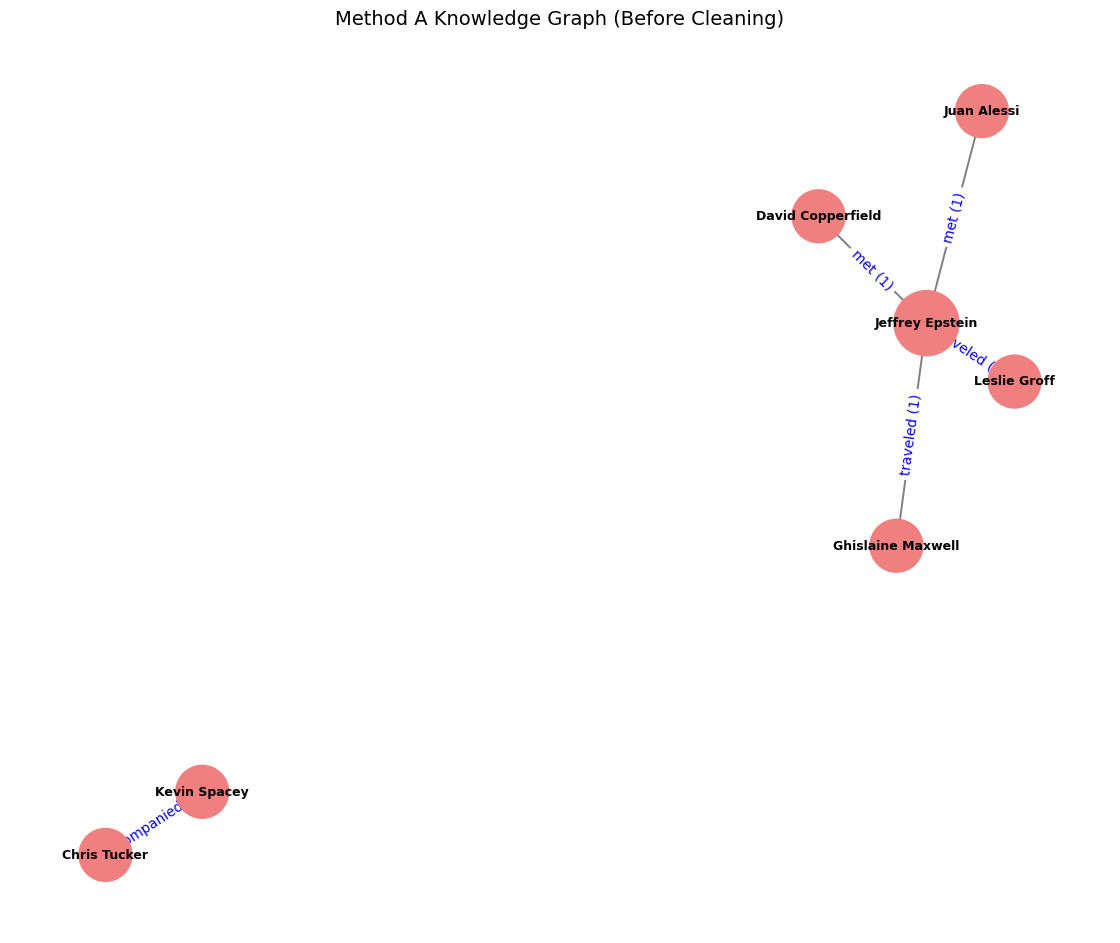

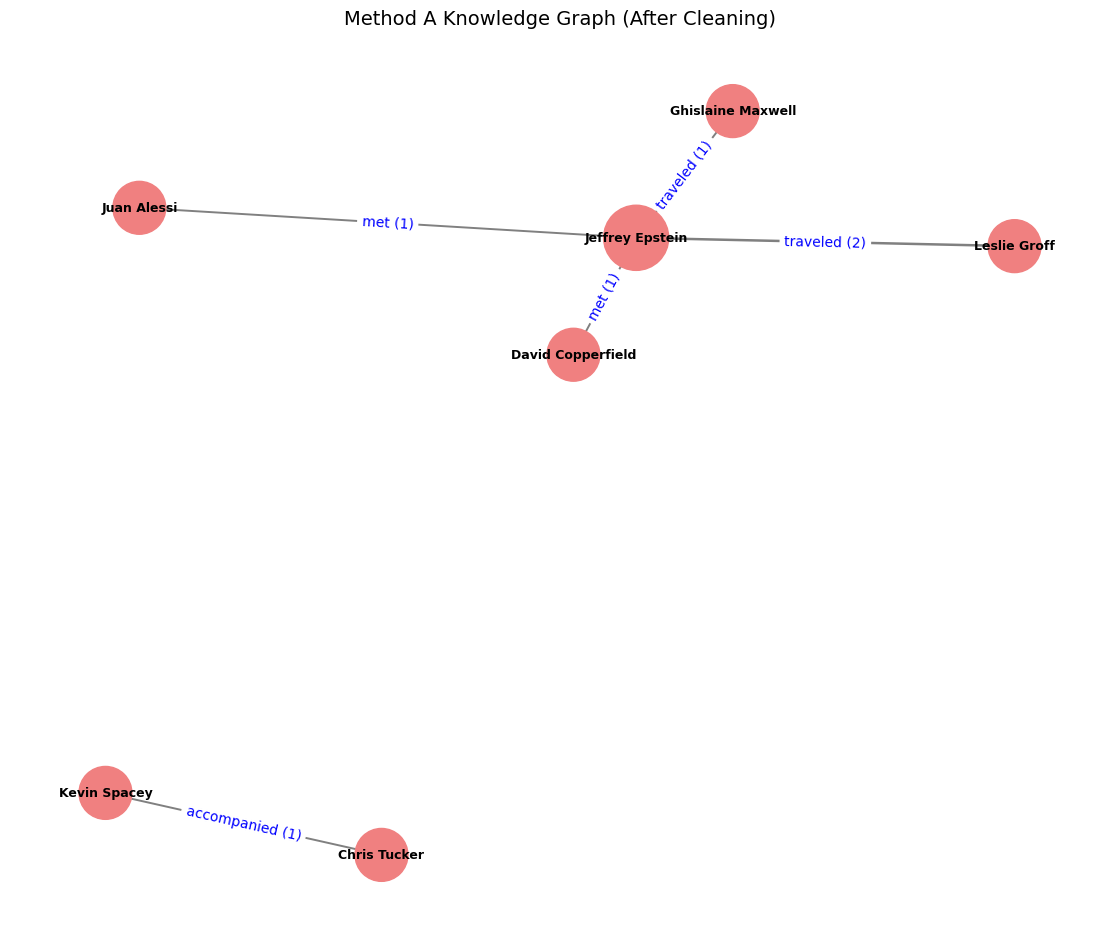

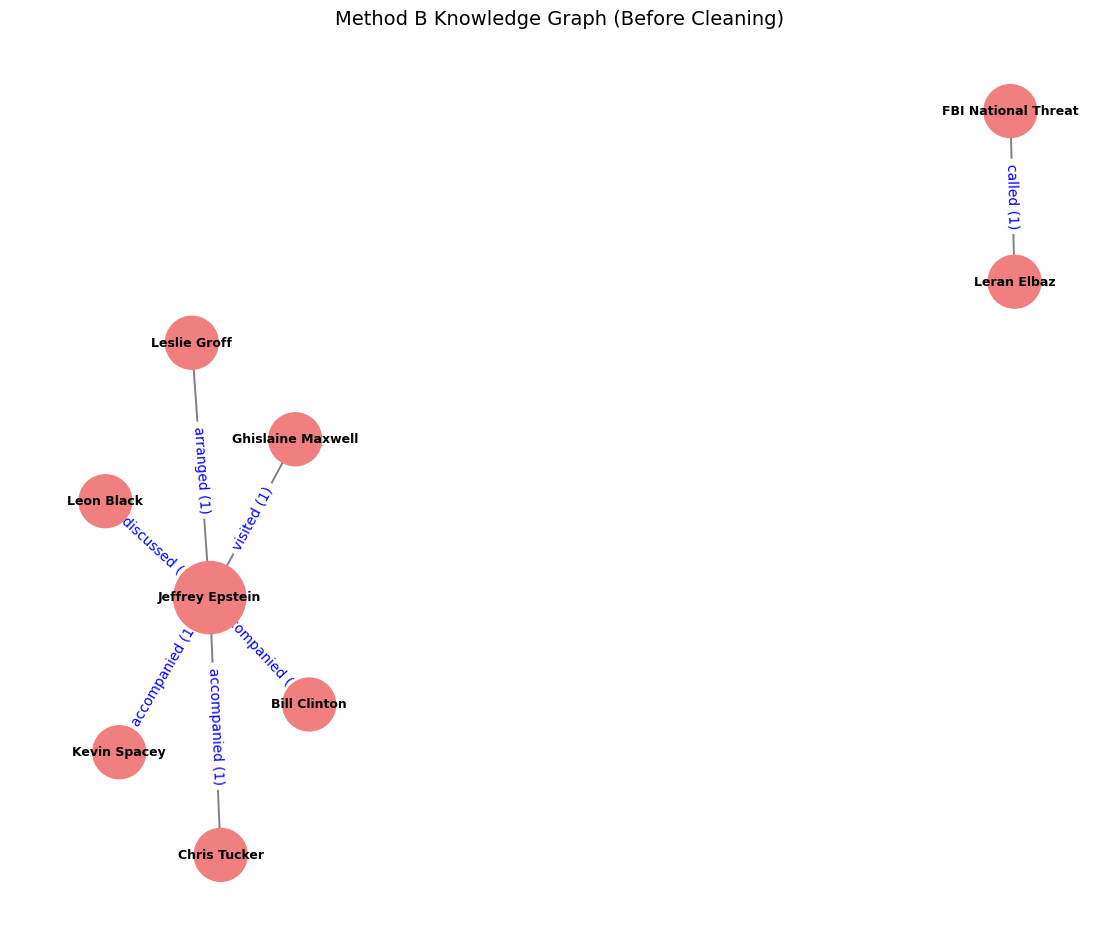

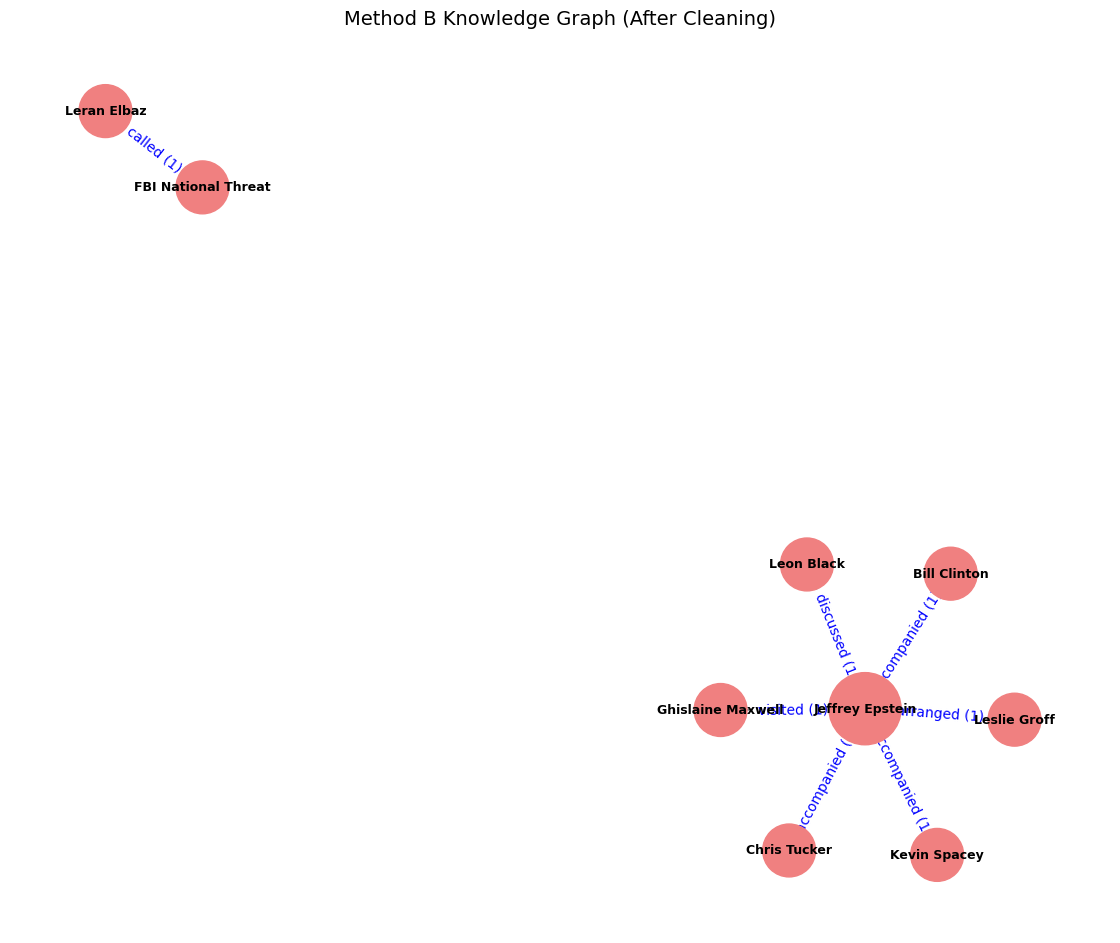

In [61]:
import networkx as nx
import matplotlib.pyplot as plt

def build_edge_summary(df_relations):
    return (
        df_relations.groupby(['Entity1', 'Entity2', 'Interaction'], as_index=False)['Mentions']
        .max()
        .rename(columns={'Mentions': 'Weight'})
    )

def draw_knowledge_graph(df_relations, title, seed=42):
    if df_relations is None or df_relations.empty:
        print(f'{title}: no relations were found to plot.')
        return

    edge_summary = build_edge_summary(df_relations)
    graph = nx.Graph()

    for _, row in edge_summary.iterrows():
        label = f"{row['Interaction']} ({int(row['Weight'])})"
        graph.add_edge(row['Entity1'], row['Entity2'], label=label, weight=float(row['Weight']))

    plt.figure(figsize=(11, 9))
    pos = nx.spring_layout(graph, seed=seed)

    node_sizes = [1200 + 250 * graph.degree(node) for node in graph.nodes()]
    edge_widths = [1 + graph[u][v]['weight'] * 0.4 for u, v in graph.edges()]

    nx.draw(
        graph,
        pos,
        with_labels=True,
        node_color='lightcoral',
        node_size=node_sizes,
        font_size=9,
        font_weight='bold',
        edge_color='gray',
        width=edge_widths,
    )

    edge_labels = nx.get_edge_attributes(graph, 'label')
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_color='blue')

    plt.title(title, fontsize=14)
    plt.show()

draw_knowledge_graph(
    df_rel_before_clean if 'df_rel_before_clean' in globals() else None,
    title='Method A Knowledge Graph (Before Cleaning)',
    seed=41,
)

draw_knowledge_graph(
    df_rel if 'df_rel' in globals() else None,
    title='Method A Knowledge Graph (After Cleaning)',
    seed=42,
)

draw_knowledge_graph(
    df_rel_llm_before_clean if 'df_rel_llm_before_clean' in globals() else None,
    title='Method B Knowledge Graph (Before Cleaning)',
    seed=98,
)

draw_knowledge_graph(
    df_rel_llm if 'df_rel_llm' in globals() else None,
    title='Method B Knowledge Graph (After Cleaning)',
    seed=99,
)